In [4]:
from pathlib import Path
import pandas as pd
import json
import numpy as np
import torch
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import pickle
from datasets import load_dataset

In [2]:
from read_outputs import read_results, load_mc_harm_estimates, judge_threshold_ablation, make_log_log_plots

In [3]:
model_log = "/gpfs/data/ranganathlab/singhr36/rare-generations/model_outputs/Llama-3.2-1B-Instruct/20250827_080849"

In [6]:
model_comparison_arr_path = Path(model_log) / "model_comparison.pkl"

In [8]:
with open(model_comparison_arr_path, 'rb') as f:
    model_comparison_arr = pickle.load(f)

In [15]:
mc_arr = []
is_arr = []
threshold = 0.4

for idx in range(len(model_comparison_arr['threshold_mc_means'])):
    mc_arr.append(model_comparison_arr['threshold_mc_means'][idx][threshold])
    is_arr.append(model_comparison_arr['threshold_is_means'][idx][threshold])

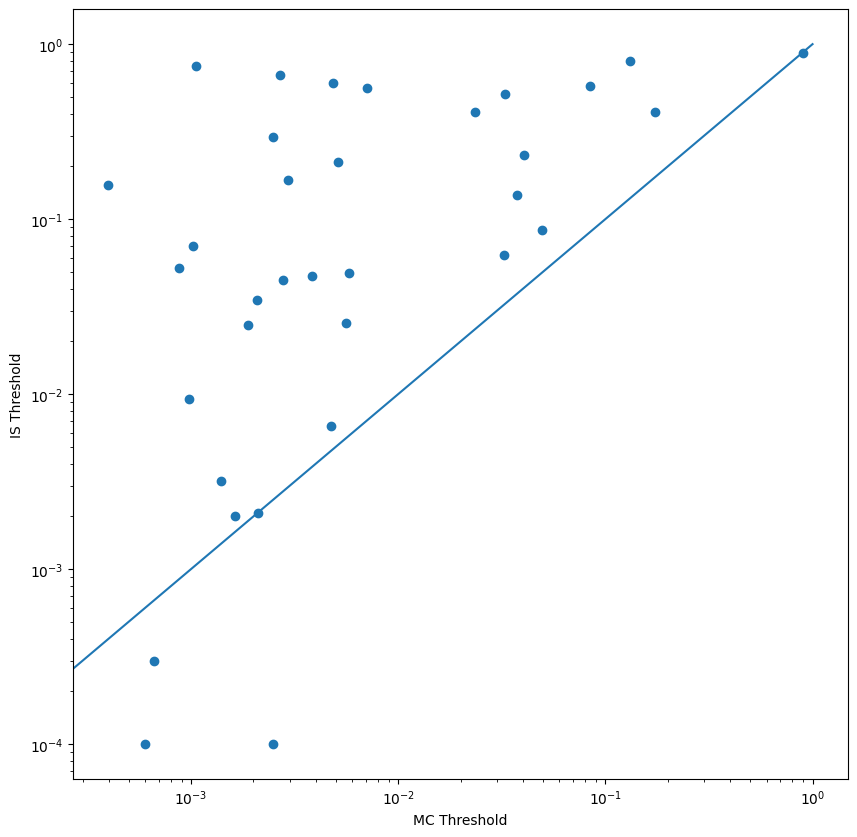

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=100)
ax.scatter(is_arr, mc_arr)
ax.plot(np.linspace(0, 1, 100), np.linspace(0,1,100))
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("MC Threshold")
ax.set_ylabel("IS Threshold")

plt.show()
plt.close()

In [ ]:
# output_path = "./model_outputs"
# mc_harm_path = "./monte_carlo_estimates/results/strong_reject/"

# model_name_arr = list(Path(output_path).iterdir())

# # model_name = "meta-llama-3-8b-instruct"

# for model_name in model_name_arr:
#     print(model_name)

#     mc_harm_estimates = load_mc_harm_estimates(mc_harm_path, model_name.name)
#     is_model_logs = read_results(
#         output_path=output_path,
#         model_name=model_name.name,
#         mc_harm_estimates=mc_harm_estimates,
#     )            

#     model_comparison_arr = judge_threshold_ablation(mc_model_logs=mc_harm_estimates, is_model_logs=is_model_logs)

#     # make_log_log_plots(model_comparison_arr)

#     fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=100)
#     ax.scatter(model_comparison_arr['mc_score_mean'], model_comparison_arr['is_score_mean'])
#     ax.plot(np.linspace(0, 1, 100), np.linspace(0,1,100))
#     ax.set_xscale("log")
#     ax.set_yscale("log")
#     ax.set_xlabel("MC Threshold")
#     ax.set_ylabel("IS Threshold")
    
#     plt.show()
#     plt.close()